In [ ]:
!pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)
print("Classes:", np.unique(y))

Shape: (569, 30)
Classes: [0 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.8214 - loss: 0.4755 - val_accuracy: 0.9560 - val_loss: 0.3089
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9313 - loss: 0.2639 - val_accuracy: 0.9670 - val_loss: 0.2053
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9560 - loss: 0.1818 - val_accuracy: 0.9670 - val_loss: 0.1607
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9643 - loss: 0.1402 - val_accuracy: 0.9670 - val_loss: 0.1361
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9725 - loss: 0.1145 - val_accuracy: 0.9670 - val_loss: 0.1212
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9753 - loss: 0.0991 - val_accuracy: 0.9670 - val_loss: 0.1102
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9808 - loss: 0.0872 - val_accuracy: 0.9670 - val_loss: 0.1039
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9835 - loss: 0.0782 - val_accuracy: 0.9670 - 

In [ ]:
loss, acc = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9649 - loss: 0.0773
Test Accuracy: 0.9649122953414917


In [ ]:
explainer = shap.Explainer(model, X_train_scaled)

In [ ]:
shap_values = explainer(X_test_scaled[:100])

PermutationExplainer explainer: 101it [00:13,  4.41it/s]                         


/tmp/ipykernel_4096/2560409663.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


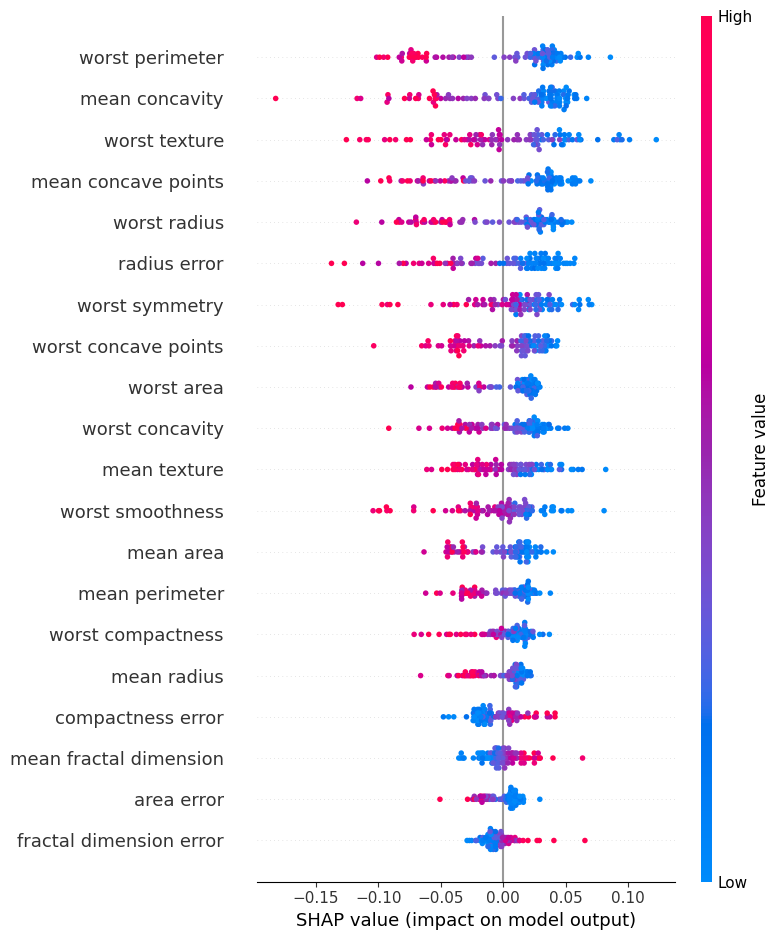

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X.columns
)

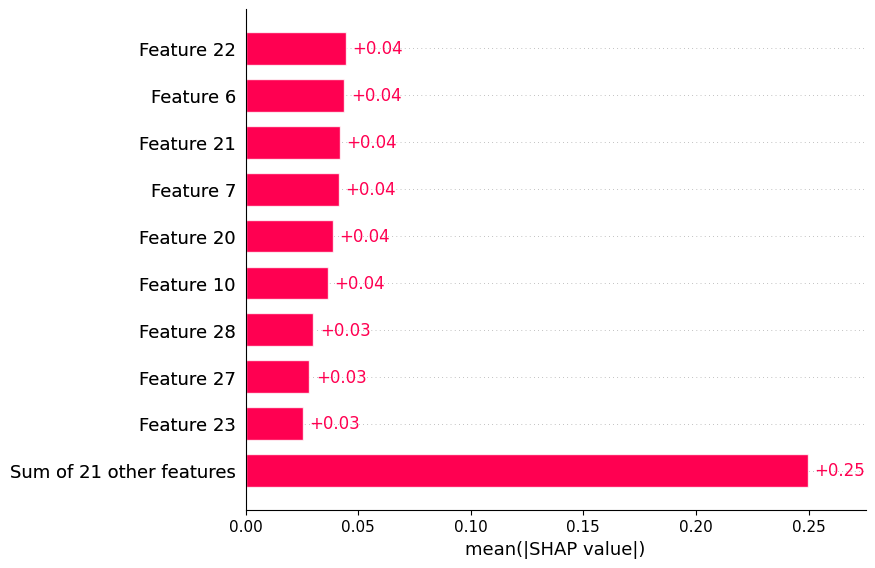

In [ ]:
shap.plots.bar(shap_values)

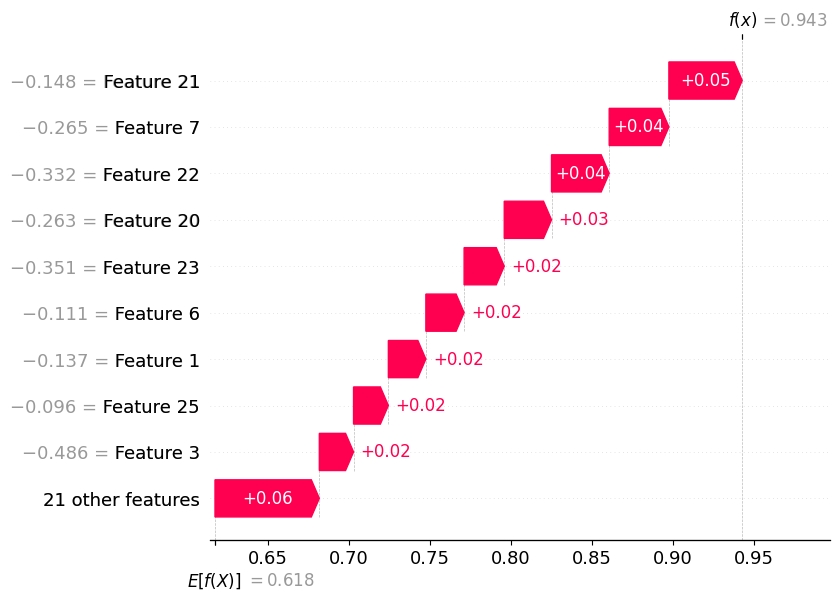

In [ ]:
shap.plots.waterfall(shap_values[0])